In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
from scipy.optimize import minimize, curve_fit
from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
from topasToDose import getDosemap
from uniformity_fit import *
from partrec_foil_plotting import partrec_foil_plotting
from RF_track_utils import *
from flatness import *


RF-Track, version 2.5.4

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
def get_s2_params(max_radius, max_thickness, N_slices, convolution_factor):
    s2_sigma = max_radius / 2
    step = max_radius / N_slices

    # Radial positions
    x = np.arange(-(max_radius + step), 0, step=step)

    # Thickness profile
    y = norm.pdf(x, 0, s2_sigma * convolution_factor)
    y = y - np.min(y)
    y *= max_thickness / np.max(y)
    # plt.scatter(x, y)
    slice_widths = np.diff(y) #thicknesses of each slice in L
    slice_radii = np.abs(x[1:])   # Corresponding radii (height)

    return slice_radii, slice_widths
            

In [4]:

s2_thickness = [0.688, 0.778, 0.581, 0.386]
s2_radii = [0.4, 0.8, 1.2, 1.6]
get_s2_params(1.6, 2.433, 4, 1)

(array([1.6, 1.2, 0.8, 0.4]),
 array([0.2651834 , 0.54928535, 0.8178421 , 0.80068915]))

In [2]:

mass = rft.electronmass    # particle mass in MeV/c^2
population = 10 * rft.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 250
N_particles = int(100000)
charge = -1


# x, y, xp, yp = (rft.qrandn(N_particles, 4) * [1, 1, 0.01, 0.01]).T


# P = np.ones(N_particles) * P_ref
# T = np.zeros(N_particles)
# matrix = np.column_stack((x, xp, y, yp, T, P)) #transpose to match Bunch6d format
# B0 = rft.Bunch6d(mass, N_particles, charge, matrix)

Twiss = rft.Bunch6d_twiss()

Twiss.beta_x = 60        # m
Twiss.beta_y = 80      # m
Twiss.alpha_x = 0
Twiss.alpha_y = 0
Twiss.emitt_x = 17.3    # mm.mrad normalised emittance
Twiss.emitt_y = 12.3     # mm.mrad
# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)      








In [ ]:
def loss (params, B0, target_size=16):
    s1_l, s2_width, s2_depth = params
    '''params dimensions in mm'''
    lattice = rft.Lattice()
    window = rft.Absorber(250e-6,'beryllium')
    window.disable_energy_straggling()
    window.set_shape ('circular', 0.5,0.5 )
    lattice.append(window)
    lattice.append(rft.Drift(0.5))  #drift to s1
    
    S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
    S1.disable_energy_straggling()
    S1.set_shape ('circular', 1,1  )
    
    lattice.append(S1)
    

    lattice.append(rft.Drift(0.5))  #drift to S2
    # lattice.append(rft.Drift(0.532))  #drift to S2

    s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
  
    for i in range(len(s2_l)):
        Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
        Slice.disable_energy_straggling()
        Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
        # Slice.set_shape ('circular', 2,2 )
        lattice.append(Slice)

    lattice.append(rft.Drift(0.5))  #drift to phsp
    # lattice.append(rft.Drift(2.204))

    B1 = lattice.track(B0)
    I = B1.get_info()
    sx, sy, ax, ay= I.sigma_x, I.sigma_y, I.alpha_x, I.alpha_y
    # T = lattice.get_transport_table(
    # '%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
    M = B1.get_phase_space('%x %xp %y %yp %E %z')
   
    

    # loss = flatness(hist_x) + flatness(hist_y)
    # loss = merit_beam_Uniform(B1, 5, 20, transmission=0.998)
    # loss = sx**2 + sy**2 + (sx-sy)**2 + (ax-ay)**2 
    masked_x, masked_y = mask2d(M[:,0],M[:,2])
    loss = nearest_neighbor_test(masked_x,masked_y)[2] + abs(masked_x.max()/target_size-1) + abs(int(B1.get_population())/int(B0.get_population()) - 1)
    
    print('loss:', loss, 's1_l:', s1_l, 's2_2r:', s2_width, 's2_l:', s2_depth)
    return loss

In [ ]:
# B0_opt = rft.Bunch6d(mass, 10000, charge, matrix)
B0_opt = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, 10000)   
x0 = [2,6,10]
res = minimize(loss,
                      x0=x0, args=(B0),
                      bounds=[ (0,5),(0,20),(0,20)], 
                      method='Powell',
                      options={'disp': True
                               , 'xtol':0.1}
                    #   tol=1e-2
                      )

print(f'Trial: M={res.fun:.2f}, params, ={res.x}')

loss: 24953.247053434126 s1_l: 2.0 s2_2r: 6.0 s2_l: 10.0
loss: 22388.804716210325 s1_l: 1.9098300562505255 s2_2r: 6.0 s2_l: 10.0
loss: 17260.0464562015 s1_l: 3.0901699437494736 s2_2r: 6.0 s2_l: 10.0
loss: 13749.020567910531 s1_l: 3.819660112501051 s2_2r: 6.0 s2_l: 10.0
loss: 11717.244274691277 s1_l: 4.270509831248423 s2_2r: 6.0 s2_l: 10.0
loss: 10302.65331340894 s1_l: 4.549150281252629 s2_2r: 6.0 s2_l: 10.0
loss: 10175.136087016248 s1_l: 4.721359549995794 s2_2r: 6.0 s2_l: 10.0
loss: 10124.079516966267 s1_l: 4.67374922724626 s2_2r: 6.0 s2_l: 10.0
loss: 10273.82848286795 s1_l: 4.640415854254816 s2_2r: 6.0 s2_l: 10.0
loss: 9807.50006701867 s1_l: 4.67374922724626 s2_2r: 7.639320225002102 s2_l: 10.0
loss: 8933.909662428225 s1_l: 4.67374922724626 s2_2r: 12.360679774997894 s2_l: 10.0
loss: 8696.20037505203 s1_l: 4.67374922724626 s2_2r: 15.278640450004204 s2_l: 10.0
loss: 8649.276928957928 s1_l: 4.67374922724626 s2_2r: 16.824196386265783 s2_l: 10.0
loss: 8514.166621690681 s1_l: 4.6737492272462

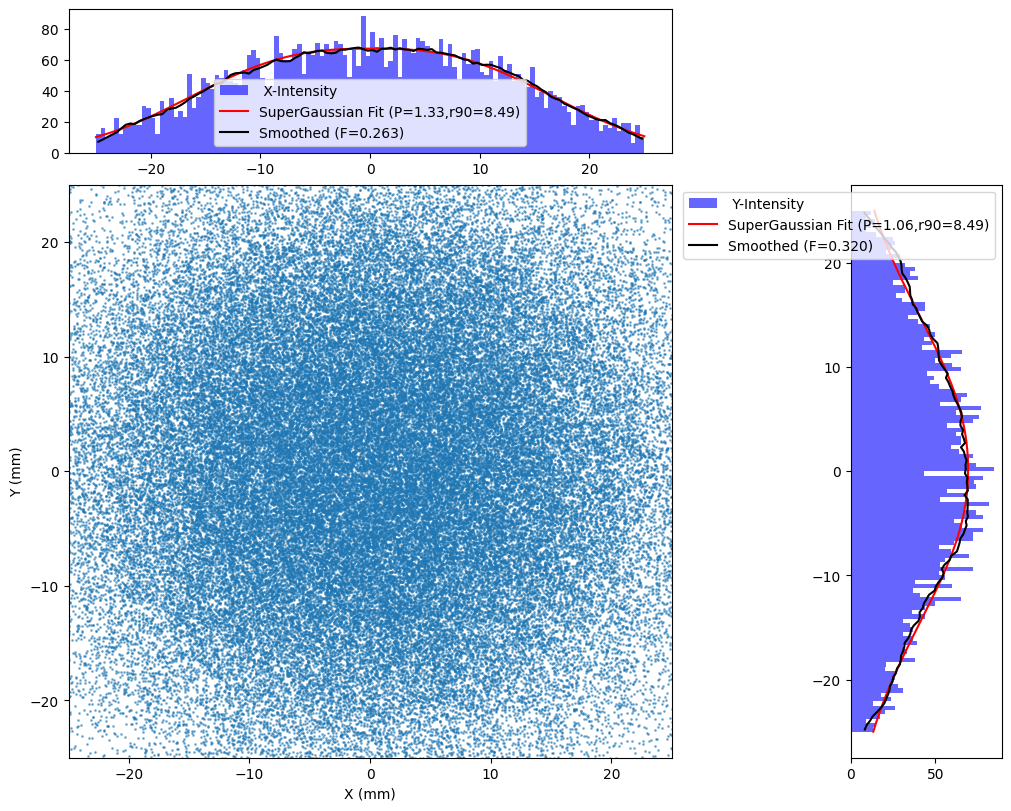

In [ ]:
# s1_l, s2_width, s2_depth = 2.27403378, 3.80651473, 4.52916474
# s1_l, s2_width, s2_depth = 4.91777743,  8.00924655, 12.33363883
s1_l, s2_width, s2_depth = res.x
lattice = rft.Lattice()
window = rft.Absorber(250e-6,'beryllium')
window.disable_energy_straggling()
window.set_shape ('circular', 0.5,0.5 )
lattice.append(window)

lattice.append(rft.Drift(0.5))  #drift to s1

S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
# S1 = rft.Absorber(0.0001,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1 )
lattice.append(S1)

lattice.append(rft.Drift(0.5))  #drift to S2
# lattice.append(rft.Drift(0.532))  #drift to S2
s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)
for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    # Slice.set_shape ('circular', 2,2 )
    lattice.append(Slice)

lattice.append(rft.Drift(0.5))  #drift to phsp
# lattice.append(rft.Drift(0.5))

B1 = lattice.track(B0)
T = lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
plot_phsp(T,M,120,25)

np.float64(5751.8845778260065)

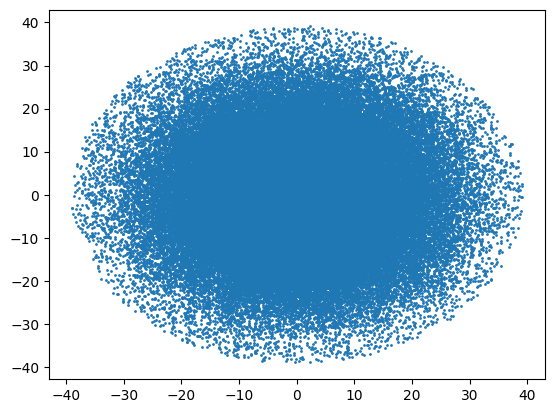

In [28]:
merit_beam_Uniform1(B1, 5, 20, transmission=0.998)

checking results

In [21]:
# B0.get_population()
B1.get_population()

62415000000.0

checking with TOPAS

In [4]:
#twiss to 6d params
Twiss.beta_x = 60        # m
Twiss.beta_y = 80      # m
Twiss.alpha_x = 0
Twiss.alpha_y = 0
Twiss.emitt_x = 17.3    # mm.mrad normalised emittance
Twiss.emitt_y = 12.3     # mm.mrad

geo_emitt_x = Twiss.emitt_x / (P_ref / mass) #beta*gamma = p/mc
geo_emitt_y = Twiss.emitt_y / (P_ref/ mass)
sig_x = np.sqrt(Twiss.beta_x * geo_emitt_x)
sig_y = np.sqrt(Twiss.beta_y * geo_emitt_y)
sig_xp = Twiss.alpha_x * np.sqrt(geo_emitt_x / Twiss.beta_x)
sig_yp = Twiss.alpha_y * np.sqrt(geo_emitt_y / Twiss.beta_y)


Welcome to TOPAS, Tool for Particle Simulation (Version 3.9)
Loading parameters starting from: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt


Topas is exiting due to a serious error in parameter file: /Users/sabrinawang/Desktop/DPhil_Project/topas_main.txt
Parameter name: s:Ge/S1/Type
Parameter has already been defined elsewhere in this same file
/Users/sabrinawang/Desktop/DPhil_Project/topasToDose.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


(100, 100)
(100,)
(100,)
(100, 100)
[-19.8 -19.4 -19.  -18.6 -18.2 -17.8 -17.4 -17.  -16.6 -16.2 -15.8 -15.4
 -15.  -14.6 -14.2 -13.8 -13.4 -13.  -12.6 -12.2 -11.8 -11.4 -11.  -10.6
 -10.2  -9.8  -9.4  -9.   -8.6  -8.2  -7.8  -7.4  -7.   -6.6  -6.2  -5.8
  -5.4  -5.   -4.6  -4.2  -3.8  -3.4  -3.   -2.6  -2.2  -1.8  -1.4  -1.
  -0.6  -0.2   0.2   0.6   1.    1.4   1.8   2.2   2.6   3.    3.4   3.8
   4.2   4.6   5.    5.4   5.8   6.2   6.6   7.    7.4   7.8   8.2   8.6
   9.    9.4   9.8  10.2  10.6  11.   11.4  11.8  12.2  12.6  13.   13.4
  13.8  14.2  14.6  15.   15.4  15.8  16.2  16.6  17.   17.4  17.8  18.2
  18.6  19.   19.4  19.8]


/Users/sabrinawang/Desktop/DPhil_Project/uniformity_fit.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


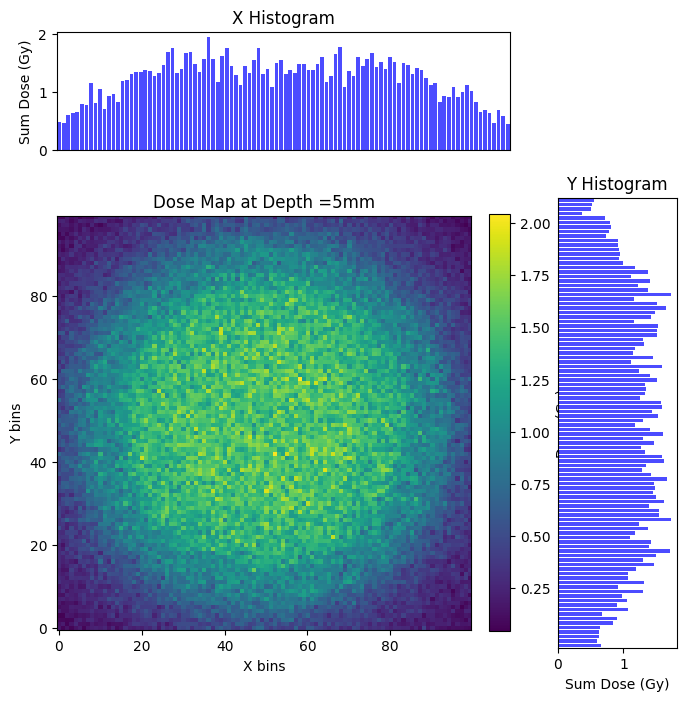

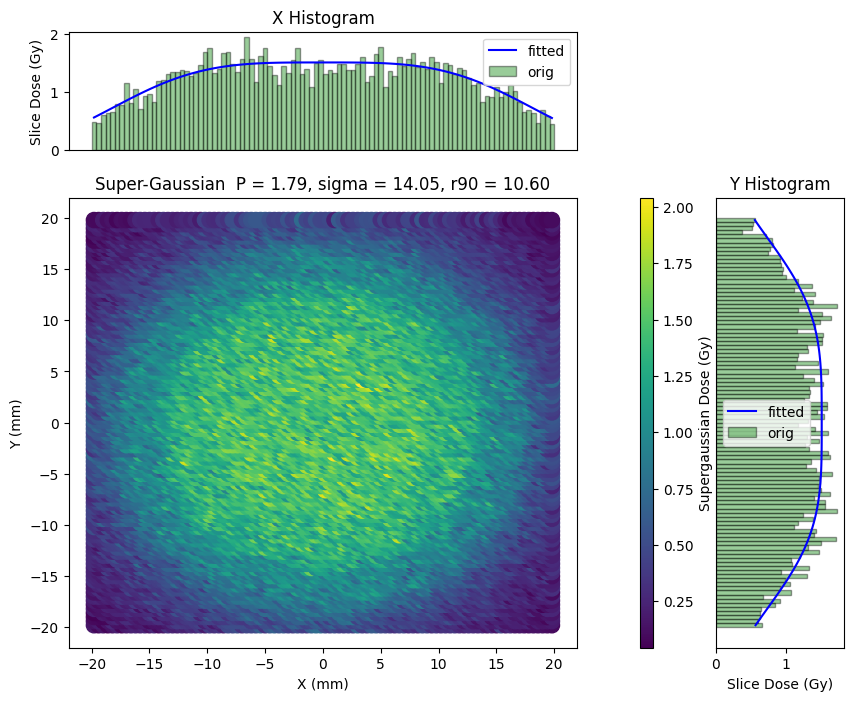

In [6]:
output_filename='CLEAR_no_tube_simulation'
dose_depth=5
dir = '/Users/sabrinawang/Desktop/DPhil_Project/'
profile = "dose"
N_particles = 500000

# s1_l, s2_width, s2_depth = 2.27403378, 3.80651473, 4.52916474 '''works great'''
s1_l, s2_width, s2_depth = 3.19, 2.747*2, 12
# s1_l, s2_width, s2_depth = res.x
s1_l, s2_width, s2_depth = 4.91777743,  8.00924655, 12.33363883

setup = partrec_gaussian_optimiser_utils(world_material="Air")

setup.generate_phsp_beam(sig_x,sig_y,sig_xp,sig_yp,P_ref,0,N_particles)

setup.add_flat_scatterer(0.25,"Beryllium",1)

setup.add_flat_scatterer(s1_l,"Aluminum",501)

setup.add_gaussian_scatterer(s2_depth,s2_width,1,4,"PEEK",1001)

if profile == "dose":
    setup.add_tank_bins(1501, dose_depth, 100,100,1,output_filename,width=40)
elif profile == "intensity":
    setup.add_patient(1501)

setup.run_topas(view_setup=False)

if profile == "dose":
#             # initialise plotting class
    doseMap = getDosemap("DoseAtTank"+str(dose_depth)+ "_"+ output_filename+".csv",N_particles, dose_depth, output_filename, plot = True) 
    fitDoseMap(N_particles, dose_depth,output_filename)

elif profile == "intensity":
    plotter = partrec_foil_plotting('patient_beam.phsp' ) #filename defined inside partrec_gaussian_optimiser_utils
    # plot transverse distributions and energy spectrum at patient
    plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'e',fov= 20, col=10)
    plotter.show_transverse_beam(output_filename, s1_l, s2_depth, s2_width,particle= 'y',fov=20, col=10)